# Stack Overflow Developer Survey 2023 — Introductory Analysis

In [63]:
!pip install category_encoders

In [64]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import category_encoders as ce
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [65]:
# Load data
survey_data=pd.read_csv('survey_results_public.csv',sep=',')
survey_data

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89179,89180,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Bootstrapping a business;Freelance/contr...,"Associate degree (A.A., A.S., etc.)",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89180,89181,I agree,I am a developer by profession,18-24 years old,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Online Courses or Certification;Othe...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN
89181,89182,I agree,I code primarily as a hobby,Prefer not to say,I prefer not to say,NaN,NaN,Something else,Books / Physical media;Hackathons (virtual or ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN
89182,89183,I agree,I am a developer by profession,Under 18 years old,"Employed, part-time;Student, part-time","Hybrid (some remote, some in-person)",Hobby;School or academic work,"Secondary school (e.g. American high school, G...",Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN


In [66]:
survey_data.columns

Index(['ResponseId', 'Q120', 'MainBranch', 'Age', 'Employment', 'RemoteWork',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       'LearnCodeCoursesCert', 'YearsCode', 'YearsCodePro', 'DevType',
       'OrgSize', 'PurchaseInfluence', 'TechList', 'BuyNewTool', 'Country',
       'Currency', 'CompTotal', 'LanguageHaveWorkedWith',
       'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith',
       'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith',
       'PlatformWantToWorkWith', 'WebframeHaveWorkedWith',
       'WebframeWantToWorkWith', 'MiscTechHaveWorkedWith',
       'MiscTechWantToWorkWith', 'ToolsTechHaveWorkedWith',
       'ToolsTechWantToWorkWith', 'NEWCollabToolsHaveWorkedWith',
       'NEWCollabToolsWantToWorkWith', 'OpSysPersonal use',
       'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith',
       'OfficeStackAsyncWantToWorkWith', 'OfficeStackSyncHaveWorkedWith',
       'OfficeStackSyncWantToWorkWith', 'AISearchHaveWorkedWith',
       'AISearchWan

# Questions with respect to columns
1. ResponseId → Respondent unique identifier (system field)
 2. Q120 → Internal survey routing/placeholder (no end-user question)
 3. MainBranch → Which of the following options best describes you today? For the purpose of this survey, a developer is "someone who writes code".
 4. Age → What is your age?
 5. Employment → Which of the following best describes your current employment status? Select all that apply.
 6. RemoteWork → Which best describes your current work situation?
 7. CodingActivities → Which of the following best describes the code you write outside of work? Select all that apply.
 8. EdLevel → Which of the following best describes the highest level of formal education that you’ve completed?
 9. LearnCode → How do you learn to code? Select all that apply.
 10. LearnCodeOnline → What online resources do you use to learn to code? Select all that apply.
 11. LearnCodeCoursesCert → What online courses or certifications do you use to learn to code? Select all that apply.
 12. YearsCode → Including any education, how many years have you been coding in total?
 13. YearsCodePro → NOT including education, how many years have you coded professionally (as a part of your work)?
 14. DevType → Which of the following describes your current job, the one you do most of the time? Please select only one.
 15. OrgSize → Approximately how many people are employed by the company or organization you currently work for?
 16. PurchaseInfluence → What level of influence do you, personally, have over new technology purchases at your organization?
 17. TechList → When thinking about new technology purchases at your organization, are you more likely to be given a shortlist of products/services to evaluate or be told to investigate on your own?
 18. BuyNewTool → When buying a new tool or software, how do you discover and research available solutions? Select all that apply.
 19. Country → Where do you live?
 20. Currency → Which currency do you use day-to-day? If your answer is complicated, please pick the one you're most comfortable estimating in.
 21. CompTotal → What is your current total annual compensation (salary, bonuses, and perks, before taxes and deductions)?

22. Language → Which programming, scripting, and markup languages have you done extensive development work in over the past year, and which do you want to work with next year?
 (maps to 2 columns: LanguageHaveWorkedWith, LanguageWantToWorkWith)

23. Database → Which database environments have you done extensive development work in over the past year, and which do you want to work with next year?
 (maps to 2 columns: DatabaseHaveWorkedWith, DatabaseWantToWorkWith)

24. Platform → Which platforms have you done extensive development work for over the past year, and which do you want to work with next year?
 (maps to 2 columns: PlatformHaveWorkedWith, PlatformWantToWorkWith)

25. Webframe → Which web frameworks and web technologies have you worked with extensively in the past year, and which do you want to work with next year?
 (maps to 2 columns: WebframeHaveWorkedWith, WebframeWantToWorkWith)

26. MiscTech → Which other frameworks and libraries have you worked with extensively in the past year, and which do you want to work with next year?
 (maps to 2 columns: MiscTechHaveWorkedWith, MiscTechWantToWorkWith)

27. ToolsTech → Which developer tools for compilation, build, and/or orchestration have you used extensively in the past year, and which do you want to use next year?
 (maps to 2 columns: ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith)

28. NEWCollabTools → Which development environments/collaboration tools have you used extensively in the past year, and which do you want to use next year?
 (maps to 2 columns: NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith)

29. OpSys → What is the primary operating system you use on your personal computer and at work?
 (maps to 2 columns: OpSysPersonal use, OpSysProfessional use)

30. OfficeStackAsync → Which collaborative work management and/or asynchronous tools did you use regularly over the past year, and which would you like to use next year?
 (maps to 2 columns: OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith)

31. OfficeStackSync → Which communication (synchronous) tools did you use regularly over the past year, and which would you like to use next year?
 (maps to 2 columns: OfficeStackSyncHaveWorkedWith, OfficeStackSyncWantToWorkWith)

32. AISearch → Which AI-powered search tools did you use regularly over the past year, and which would you like to use next year?
 (maps to 2 columns: AISearchHaveWorkedWith, AISearchWantToWorkWith)

33. AIDev → Which AI-powered developer tools did you use regularly over the past year, and which would you like to use next year?
 (maps to 2 columns: AIDevHaveWorkedWith, AIDevWantToWorkWith)

34. NEWSOSites → Which of the following Stack Overflow sites have you visited? Select all that apply.
35. SOVisitFreq → How frequently would you say you visit Stack Overflow?
36. SOAccount → Do you have a Stack Overflow account?
37. SOPartFreq → How frequently would you say you participate in Q&A on Stack Overflow? (ask, answer, vote for, or comment on questions)
38. SOComm → Do you consider yourself a member of the Stack Overflow community?
39. SOAI → Your perspective on Stack Overflow using AI to improve the current experience.
40. AISelect → Do you currently use AI tools in your development process?
41. AISent → How favorable is your stance on using AI tools as part of your development workflow?
42. AIAcc → For the AI tools you use, what are the MOST important benefits you are hoping to achieve? Select all that apply.
43. AIBen → How much do you trust the accuracy of the output from AI tools as part of your development workflow?
44. AITool → Which parts of your development workflow are you interested in using AI tools for / currently using / not interested in using?
 (maps to 3 columns: AIToolInterested in Using, AIToolCurrently Using, AIToolNot interested in Using)
45. AINext → Thinking about how your workflow and process could change, how do you expect AI tools will make your job different next year?
 (maps to 5 columns: AINextVery different, AINextSomewhat different, AINextNeither different nor similar, AINextSomewhat similar, AINextVery similar)

46. TBranch → Would you like to participate in the Professional Developer Series?
47. ICorPM → Are you an individual contributor or people manager?
48. WorkExp → How many years of working experience do you have?

49. Knowledge → Please rate your level of agreement with the following statements about knowledge sharing and finding information at work.
 (maps to 8 columns: Knowledge_1, Knowledge_2, Knowledge_3, Knowledge_4, Knowledge_5, Knowledge_6, Knowledge_7, Knowledge_8)

50. Frequency → How frequently do you experience each of the following at work?
 (maps to 3 columns: Frequency_1, Frequency_2, Frequency_3)

51. TimeSearching → On an average day, how much time do you typically spend searching for answers or solutions to problems you encounter at work?
52. TimeAnswering → On an average day, how much time do you typically spend answering questions you get asked at work?
53. ProfessionalTech → My company has: (statements about technology/process maturity).
54. Industry → What industry is the company you work for in?
55. SurveyLength → How do you feel about the length of the survey this year?
56. SurveyEase → How easy or difficult was this survey to complete?
57. ConvertedCompYearly → Standardized annual compensation (derived field; no direct question).

#  Základní informace o datasetu
# Dataset **Stack Overflow Developer Survey 2023** obsahuje odpovědi více než 87 000 vývojářů z celého světa.  
# Každý řádek představuje jednoho respondenta, který odpovídal na až 84 otázek.  
# Cílem je pochopit trendy v profesi vývojářů a hledat zajímavé vztahy mezi proměnnými.

In [67]:
survey_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89184 non-null  int64  
 1   Q120                                 89184 non-null  object 
 2   MainBranch                           89184 non-null  object 
 3   Age                                  89184 non-null  object 
 4   Employment                           87898 non-null  object 
 5   RemoteWork                           73810 non-null  object 
 6   CodingActivities                     73764 non-null  object 
 7   EdLevel                              87973 non-null  object 
 8   LearnCode                            87663 non-null  object 
 9   LearnCodeOnline                      70084 non-null  object 
 10  LearnCodeCoursesCert                 37076 non-null  object 
 11  YearsCode                   

# Work with Missing Values - NaN attributes
Analýza chybějících hodnot

Mnoho otázek bylo volitelných, proto se přirozeně vyskytuje větší množství `NaN`.  
Nejvíce chybějících hodnot je u specializovaných technologických otázek, méně u demografických údajů.








In [68]:
cols_null_percent = survey_data.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)
# Percentage of NaN atributes in Features

,0
AINextVery similar,97.061132
AINextSomewhat similar,93.005472
AINextNeither different nor similar,92.600691
AINextVery different,85.803507
AIDevWantToWorkWith,78.037540
...,...
Employment,1.441963
Country,1.357867
EdLevel,1.357867
AISelect,1.357867


<Axes: title={'center': 'Distribution of Missing Values in Data'}, xlabel='Column Names', ylabel='Percentage of Missing Values per Column'>

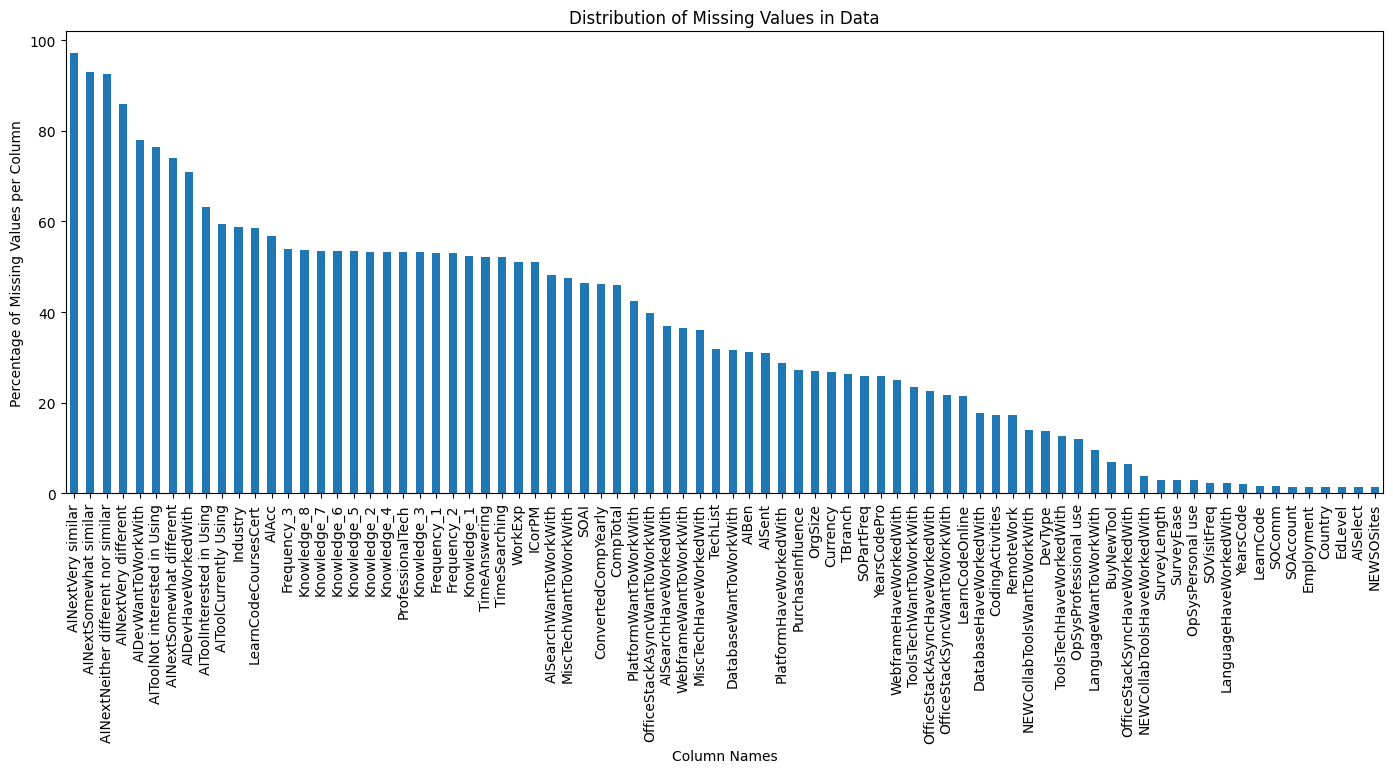

In [69]:
cols_with_null.plot(
    kind='bar',
    figsize=(17, 6),
    title='Distribution of Missing Values in Data',
    xlabel='Column Names',
    ylabel='Percentage of Missing Values per Column'
)


##  Demografie respondentů
# Většina účastníků průzkumu jsou profesionální vývojáři pracující na plný úvazek.  
# Průměrný věk se pohybuje okolo 29 let, významná část respondentů pracuje zcela nebo částečně na dálku.

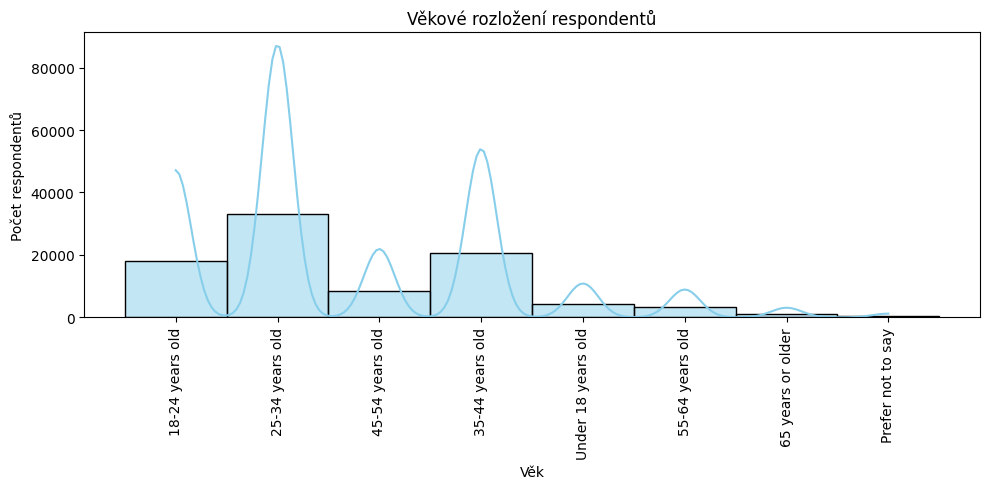

In [70]:
# Basic demographic overview
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=survey_data, x="Age", bins=25, kde=True, color="skyblue")
plt.title("Věkové rozložení respondentů")
plt.xlabel("Věk")
plt.ylabel("Počet respondentů")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


#Vzdělání a zkušenosti
Většina vývojářů má vysokoškolské vzdělání technického směru.  
Nejčastější délka profesní praxe je 5–10 let.

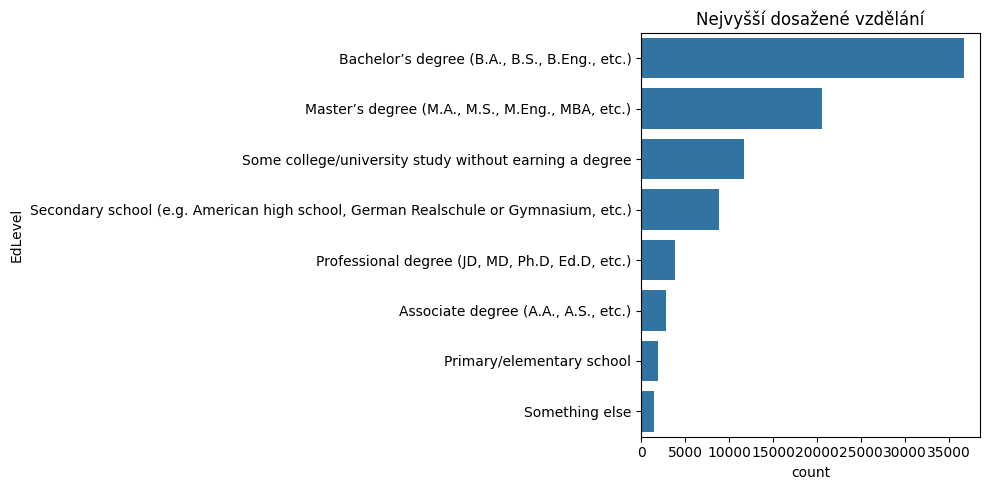

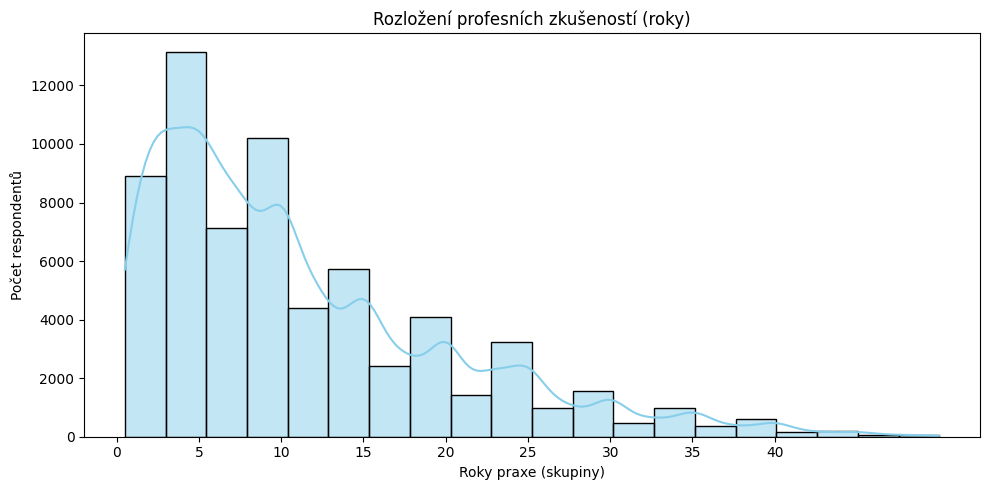

In [71]:
# Education and coding experience
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.countplot(y="EdLevel", data=survey_data, order=survey_data["EdLevel"].value_counts().index)
plt.title("Nejvyšší dosažené vzdělání")
plt.tight_layout()
plt.show()

# Clean and convert YearsCodePro column for visualization
def convert_years(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x.lower().startswith("less"):
        return 0.5
    if "more" in x.lower():
        return 35
    try:
        return float(x)
    except:
        return np.nan

survey_data["YearsCodeProNum"] = survey_data["YearsCodePro"].apply(convert_years)

# Plot histogram with clear intervals
plt.figure(figsize=(10, 5))
sns.histplot(data=survey_data, x="YearsCodeProNum", bins=20, kde=True, color="skyblue")
plt.title("Rozložení profesních zkušeností (roky)")
plt.xlabel("Roky praxe (skupiny)")
plt.ylabel("Počet respondentů")
plt.xticks(np.arange(0, 41, 5))
plt.tight_layout()
plt.show()


#Pracovní charakteristiky
# Mezi nejčastější role patří *Web Developer* a *Backend Developer*.  
# Přibližně třetina vývojářů pracuje plně vzdáleně, další třetina hybridně.

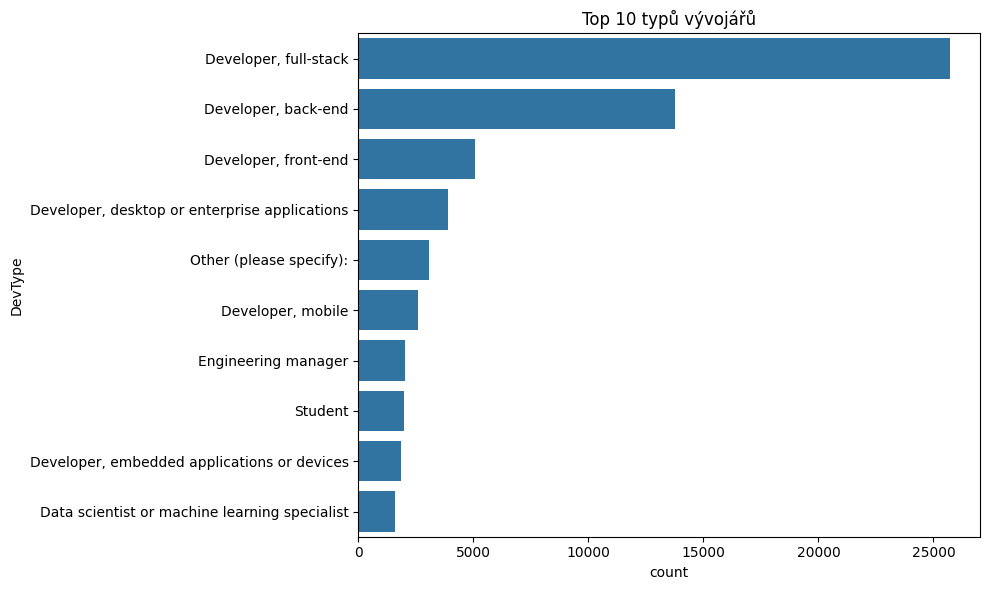

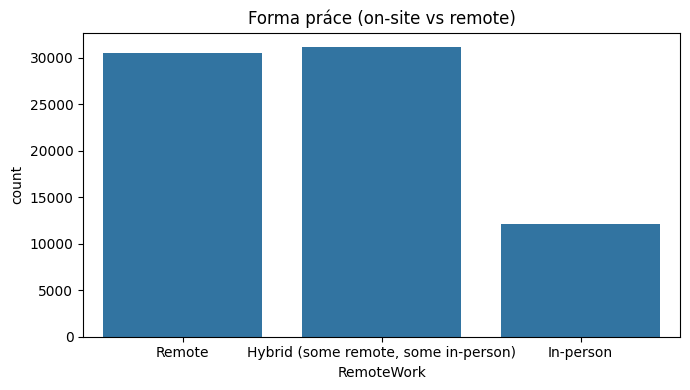

In [72]:
# Developer types and work situation
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(y="DevType", data=survey_data, order=survey_data["DevType"].value_counts().head(10).index)
plt.title("Top 10 typů vývojářů")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x="RemoteWork", data=survey_data)
plt.title("Forma práce (on-site vs remote)")
plt.tight_layout()
plt.show()

#  Geografické rozložení respondentů
# Největší zastoupení mají vývojáři ze **Spojených států**, **Německa** a **Indie**, což odpovídá
# globálnímu rozložení IT průmyslu.  
# Česká republika a Slovensko se v žebříčku nacházejí níže, ale stále poskytují dostatečný počet odpovědí
# pro lokální analýzu (v řádu stovek respondentů).

/tmp/ipython-input-2866015111.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette="crest")


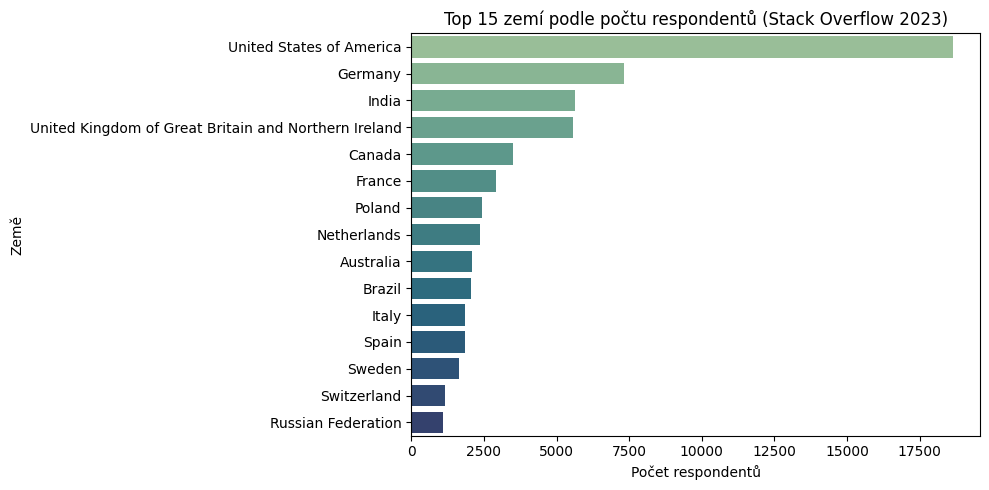

In [73]:
# Global distribution of respondents by country
# ------------------------------------------------------------
country_counts = survey_data["Country"].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.values, y=country_counts.index, palette="crest")
plt.title("Top 15 zemí podle počtu respondentů (Stack Overflow 2023)")
plt.xlabel("Počet respondentů")
plt.ylabel("Země")
plt.tight_layout()
plt.show()

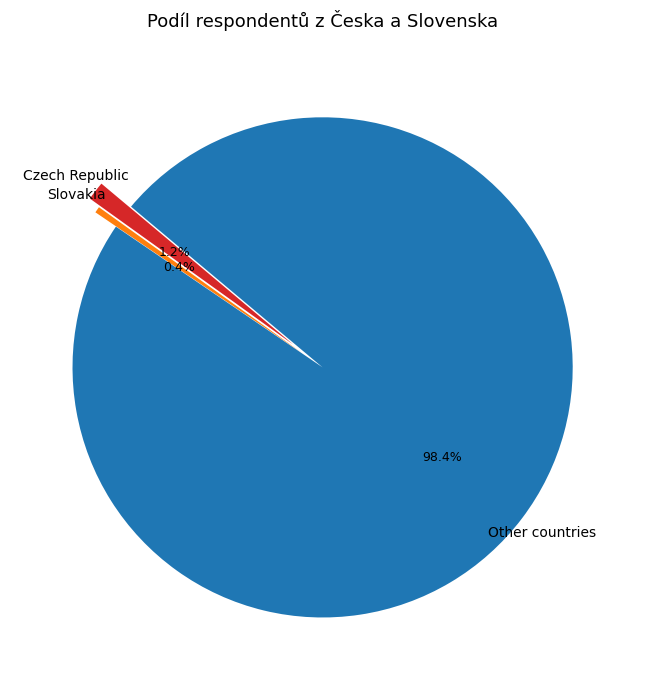

Quantity of rows of Cz and Sk 1424


In [74]:
# Share of Czech Republic and Slovakia among all respondents
cz_sk = survey_data["Country"].isin(["Czech Republic", "Slovakia"])
share_data = {
    "Czech Republic": (survey_data["Country"] == "Czech Republic").sum(),
    "Slovakia": (survey_data["Country"] == "Slovakia").sum(),
    "Other countries": (~cz_sk).sum()
}

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    share_data.values(),
    labels=share_data.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=["#d62728", "#ff7f0e", "#1f77b4"],
    explode=(0.15, 0.1, 0),
    textprops={'fontsize': 10}
)


for t in texts:
    t.set_horizontalalignment('center')
    t.set_fontsize(10)
for a in autotexts:
    a.set_fontsize(9)

plt.title("Podíl respondentů z Česka a Slovenska", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

print('Quantity of rows of Cz and Sk',survey_data[(survey_data['Country'] == 'Czech Republic')|(survey_data['Country'] == 'Slovakia')].shape[0])


# Česká republika a Slovensko společně tvoří malý, ale významný podíl respondentů.
# To umožňuje provádět srovnávací analýzy mezi těmito dvěma zeměmi a zkoumat regionální rozdíly.


In [75]:
# Výběr dat pro Českou republiku
survey_data[survey_data['Country']=='Czech Republic']

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly,YearsCodeProNum
145,146,I agree,I am a developer by profession,45-54 years old,"Independent contractor, freelancer, or self-em...",Remote,Hobby;Contribute to open-source projects,Something else,"Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neither easy nor difficult,NaN,31.0
477,478,I agree,"I am not primarily a developer, but I write co...",18-24 years old,"Not employed, but looking for work;Student, fu...",NaN,NaN,"Secondary school (e.g. American high school, G...",Colleague;On the job training;Other online res...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
522,523,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Online Course...,Formal documentation provided by the owner of ...,...,3-5 times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Manufacturing, Transportation, or Supply Chain",Appropriate in length,Easy,NaN,6.0
599,600,I agree,I code primarily as a hobby,Under 18 years old,"Not employed, and not looking for work",NaN,NaN,Primary/elementary school,Friend or family member;Other online resources...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
635,636,I agree,I am a developer by profession,25-34 years old,"Independent contractor, freelancer, or self-em...",Remote,Hobby;Contribute to open-source projects;Profe...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Colleague;Online Courses or Certification;On t...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,42036.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88728,88729,I agree,I code primarily as a hobby,18-24 years old,"Employed, full-time",In-person,Hobby,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
88846,88847,I agree,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Contribute to open-source projects;Profe...,Some college/university study without earning ...,Online Courses or Certification;Other online r...,Formal documentation provided by the owner of ...,...,3-5 times a week,1-2 times a week,60-120 minutes a day,Less than 15 minutes a day,DevOps function;Automated testing;Observabilit...,"Information Services, IT, Software Development...",Appropriate in length,Neither easy nor difficult,31846.0,4.0
89016,89017,I agree,I am a developer by profession,18-24 years old,"Student, full-time;Employed, part-time","Hybrid (some remote, some in-person)",Hobby;Contribute to open-source projects;Schoo...,"Secondary school (e.g. American high school, G...",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
89060,89061,I agree,I code primarily as a hobby,Under 18 years old,"Student, full-time;Not employed, and not looki...",NaN,NaN,Primary/elementary school,Friend or family member;Other online resources...,Formal documentation provided by the owner of ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


# Analýza mezd – Česká republika
# Tento graf ukazuje rozložení měsíčních mezd vývojářů v České republice (v CZK).  
# Hodnoty byly očištěny od extrémních odlehlých pozorování (1. a 99. percentil) a převedeny
# na měsíční bázi.  
#
# Mediánová měsíční mzda se pohybuje přibližně kolem **100 000 CZK**, zatímco horní kvartil
# dosahuje zhruba **150 000 CZK**.  
#
# Vysoká variabilita platů odráží rozdíly mezi juniorskými a seniorskými pozicemi, typem zaměstnání
# a technologickým zaměřením vývojářů.

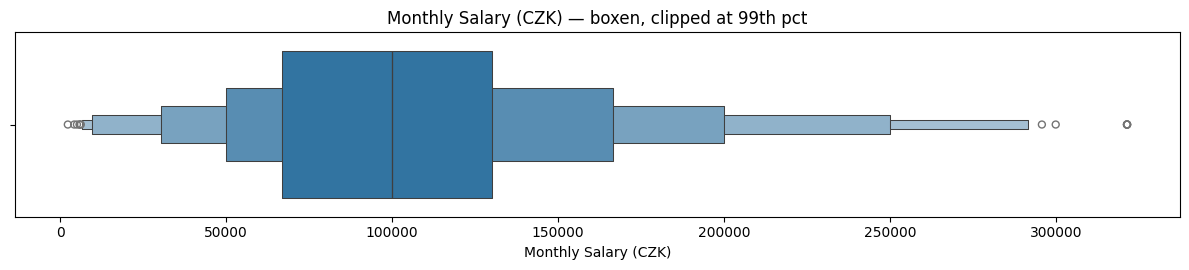

In [76]:
df_cz = survey_data[(survey_data['Country']=='Czech Republic') &
                    (survey_data['Currency'].str.contains('CZK', na=False))].copy()
df_cz['MonthSalary'] = df_cz['CompTotal'] / 12
s = df_cz['MonthSalary'].dropna()
s = s[(s>0)]
lo, hi = s.quantile([0.01, 0.99])
s_clip = s.clip(lo, hi)
plt.figure(figsize=(12,2.8))
sns.boxenplot(x=s.clip(upper=hi))
plt.title('Monthly Salary (CZK) — boxen, clipped at 99th pct')
plt.xlabel('Monthly Salary (CZK)')
plt.tight_layout()



In [77]:
survey_data[survey_data['Country'] == 'Czech Republic']['Currency'].value_counts()

,count
Currency,
CZK\tCzech koruna,672
EUR European Euro,30
USD\tUnited States dollar,19
NOK\tNorwegian krone,1
BTN\tBhutanese ngultrum,1


## Analýza používaných programovacích jazyků

Tato část kódu převádí odpovědi z vícehodnotové otázky  
`LanguageHaveWorkedWith` na seznam jazyků pro každého respondenta.  
Každý vývojář mohl uvést více jazyků, které aktivně používal během posledního roku.  

Pomocí funkcí:
- `listOfLanguages()` — převádí textový řetězec oddělený středníkem (`;`) na seznam jazyků,  
- `countLanguages()` — počítá počet jazyků, se kterými daný vývojář pracoval,  

jsme vytvořili dva nové atributy:
- **`ListOfLanguages`** — seznam jazyků pro každého respondenta,  
- **`NumOfLanguages`** — celkový počet jazyků, které respondent uvedl.

Dále byla spočítána mediánová hodnota počtu jazyků, s nimiž vývojáři pracují,  
a identifikován **nejpopulárnější programovací jazyk** mezi všemi respondenty.  

Tyto informace poskytují základní vhled do technologického prostředí vývojářů  
a budou dále využity pro hledání asociačních pravidel mezi používanými technologiemi.


##  Typ vývojáře a výše mzdy

Tento graf znázorňuje rozložení měsíčních mezd vývojářů v České republice podle jejich pracovního zaměření (`DevType`).  
Každý box představuje rozsah mezd pro danou kategorii – střední čára ukazuje medián,  
krabice zachycuje 50 % respondentů (interkvartilové rozpětí) a tečky představují odlehlé hodnoty.

Z grafu vyplývá, že:
- **nejvyšší mediánové mzdy** mají role jako *Data Scientist*, *Cloud/ML Engineer*, *Product Manager* a *Senior Executive*,  
- **nejčastější typ vývojáře** v Česku je *Full-stack* nebo *Back-end developer*, jejichž mediánová mzda se pohybuje okolo 100 000 – 120 000 CZK měsíčně,  
- **nejnižší příjmy** jsou typicky u akademických pracovníků (*Academic researcher*) a juniorních QA/tester pozic.

Tato analýza ukazuje, že specializace vývojáře má významný vliv na výši jeho mzdy,  
což je důležitý poznatek pro další fázi projektu (subgroup discovery a asociační pravidla).


,DevType,count_type
145,NaN,NaN
522,"Developer, back-end",0.252994
635,"Developer, full-stack",0.296407
729,Academic researcher,0.019461
861,"Developer, full-stack",0.296407
...,...,...
88235,"Developer, full-stack",0.296407
88318,DevOps specialist,0.019461
88521,"Developer, back-end",0.252994
88846,"Developer, QA or test",0.011976


/tmp/ipython-input-3262687361.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right')


Text(0, 0.5, 'Monthly income in CZK')

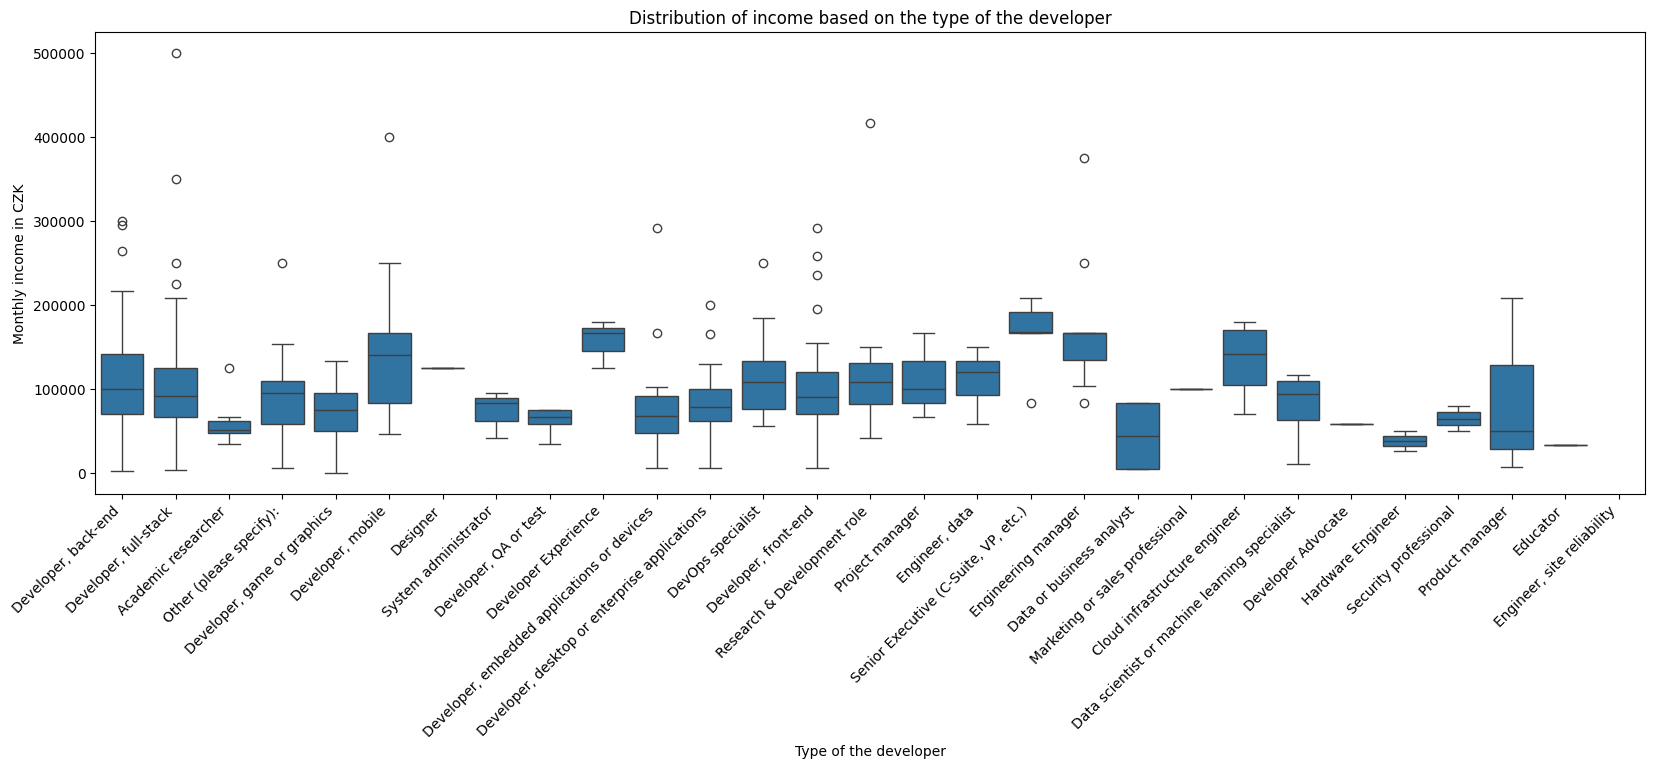

In [78]:
devtype_freq = df_cz['DevType'].value_counts(normalize= True)
df_cz['count_type'] = df_cz['DevType'].map(devtype_freq)
display(df_cz.loc[:, ['DevType', 'count_type']])

fig = plt.figure(figsize=(20, 6))
boxplot = sns.boxplot(data= df_cz, x= 'DevType', y= 'MonthSalary')
boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right')
boxplot.set_title('Distribution of income based on the type of the developer')
boxplot.set_xlabel('Type of the developer')
boxplot.set_ylabel('Monthly income in CZK')

# DATA PREPARATION


In [79]:
data_for_models = survey_data[['CompTotal', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'DevType', 'EdLevel', "YearsCodePro", 'RemoteWork', 'DatabaseHaveWorkedWith', 'WebframeHaveWorkedWith', 'Age']].copy()

In [80]:
data_for_models = data_for_models[data_for_models['CompTotal'].notna()]

data_for_models.shape

(48225, 11)

In [81]:
data_for_models.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48225 entries, 1 to 89183
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CompTotal               48225 non-null  float64
 1   Country                 48225 non-null  object 
 2   Currency                48225 non-null  object 
 3   LanguageHaveWorkedWith  48083 non-null  object 
 4   DevType                 48089 non-null  object 
 5   EdLevel                 48225 non-null  object 
 6   YearsCodePro            48023 non-null  object 
 7   RemoteWork              48126 non-null  object 
 8   DatabaseHaveWorkedWith  41940 non-null  object 
 9   WebframeHaveWorkedWith  38018 non-null  object 
 10  Age                     48225 non-null  object 
dtypes: float64(1), object(10)
memory usage: 4.4+ MB


# Work with missing values

In [82]:
cols_null_percent = data_for_models.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

,0
WebframeHaveWorkedWith,21.165371
DatabaseHaveWorkedWith,13.032659
YearsCodePro,0.418870
LanguageHaveWorkedWith,0.294453
DevType,0.282011
RemoteWork,0.205288


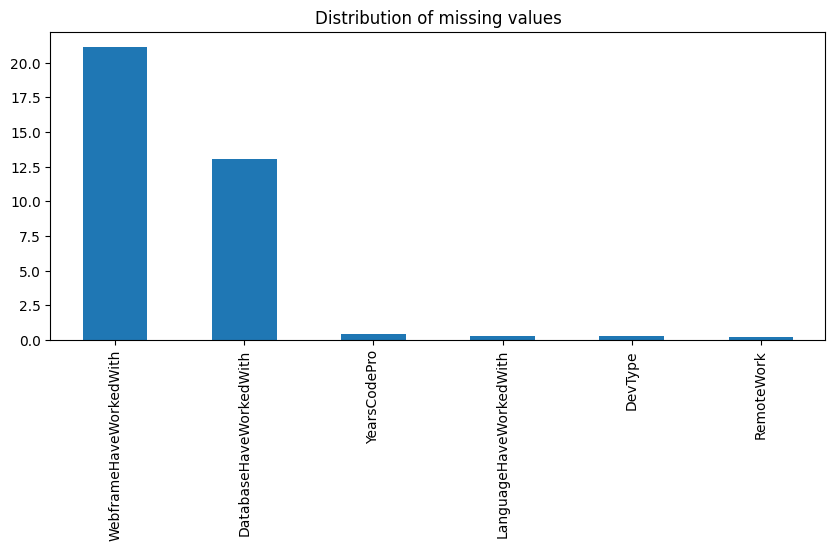

In [83]:
cols_with_null.plot(
    kind='bar',
    figsize=(10, 4),
    title='Distribution of missing values'
);

In [84]:

data_for_models = data_for_models.dropna()

data_for_models.shape

(35144, 11)

## Work with duplicates

In [85]:


dupl_columns = list(data_for_models.columns)

mask = data_for_models.duplicated(subset=dupl_columns)
df_duplicates = data_for_models[mask]
print(f'Number of duplicates: {df_duplicates.shape[0]}')
df_duplicates.drop(columns=data_for_models.columns, inplace=True)

Number of duplicates: 0


/tmp/ipython-input-1438120932.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_duplicates.drop(columns=data_for_models.columns, inplace=True)


## Low information cols

In [86]:
low_information_cols = []

for col in dupl_columns:
    #the highest relative frequency in a feature
    top_freq = data_for_models[col].value_counts(normalize=True).max()
    #the proportion of unique values ​​from the feature size
    nunique_ratio = data_for_models[col].nunique() / data_for_models[col].count()

    if top_freq > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(top_freq*100, 2)}% of simillar')

    if nunique_ratio > 0.95:
        low_information_cols.append(col)
        print(f'{col}: {round(nunique_ratio*100, 2)}% of unique')



# Exploratory Data Analysis

## Feature engineering

In [87]:


def listOfSkills(x):
  if x is not np.nan:
     return x.split(';')
  else:
    return []

In [88]:
data_for_models['ListOfLanguages'] = data_for_models['LanguageHaveWorkedWith'].apply(listOfSkills)
display(data_for_models['ListOfLanguages'])


all_languages = data_for_models['ListOfLanguages'].sum()
languages_count = Counter(all_languages)
most_popular = languages_count.most_common(1)
print('Most popular language', most_popular)

,ListOfLanguages
1,"[HTML/CSS, JavaScript, Python]"
3,"[Bash/Shell (all shells), HTML/CSS, JavaScript..."
4,"[HTML/CSS, JavaScript, TypeScript]"
5,"[Bash/Shell (all shells), HTML/CSS, JavaScript..."
6,"[Ada, Clojure, Elixir, Go, HTML/CSS, Java, Jav..."
...,...
89175,"[Java, Kotlin]"
89177,"[Bash/Shell (all shells), C#, C++, Cobol, Groo..."
89178,"[JavaScript, TypeScript]"
89179,"[HTML/CSS, Java, JavaScript, SQL, TypeScript]"


Most popular language [('JavaScript', 26926)]


In [89]:
data_for_models['ListOfDatabases'] = data_for_models['DatabaseHaveWorkedWith'].apply(listOfSkills)
display(data_for_models['ListOfDatabases'])


all_Databases = data_for_models['ListOfDatabases'].sum()
Databases_count = Counter(all_Databases)
most_popular = Databases_count.most_common(1)
print('Most popular Database', most_popular)

,ListOfDatabases
1,[Supabase]
3,"[PostgreSQL, Redis]"
4,"[BigQuery, Elasticsearch, MongoDB, PostgreSQL]"
5,"[BigQuery, Cloud Firestore, PostgreSQL, Redis]"
6,"[MariaDB, Microsoft SQL Server, MySQL, Postgre..."
...,...
89175,"[H2, MongoDB, MySQL, SQLite]"
89177,"[Firebird, IBM DB2, MariaDB, Microsoft Access,..."
89178,[Dynamodb]
89179,"[MongoDB, MySQL, PostgreSQL, SQLite]"


Most popular Database [('PostgreSQL', 18742)]


In [90]:
data_for_models['ListOfWebframe'] = data_for_models['WebframeHaveWorkedWith'].apply(listOfSkills)
display(data_for_models['ListOfWebframe'])


all_Webframes = data_for_models['ListOfWebframe'].sum()
Webframes_count = Counter(all_Webframes)
most_popular = Webframes_count.most_common(1)
print('Most popular Webframe', most_popular)

,ListOfWebframe
1,"[Next.js, React, Remix, Vue.js]"
3,"[Node.js, React, Ruby on Rails, Vue.js, WordPr..."
4,"[Express, Gatsby, NestJS, Next.js, Node.js, Re..."
5,"[Angular, Express, NestJS, Node.js]"
6,"[AngularJS, jQuery, Node.js, Phoenix, Ruby on ..."
...,...
89175,[Spring Boot]
89177,"[AngularJS, ASP.NET, CodeIgniter, Drupal, jQue..."
89178,"[Express, Node.js, Spring Boot]"
89179,"[Angular, AngularJS, Express, jQuery, Node.js,..."


Most popular Webframe [('React', 15382)]


## Coding features

In [91]:
data_for_models['Age'].value_counts()

,count
Age,
25-34 years old,16468
35-44 years old,10188
18-24 years old,3848
45-54 years old,3350
55-64 years old,1075
65 years or older,144
Under 18 years old,54
Prefer not to say,17


In [92]:
mapping = {
    'Prefer not to say': 0,
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

ord_encoder = ce.OrdinalEncoder(mapping=[{
    'col': 'Age',
    'mapping': mapping,
    'handle_unknown': 'value',
    'handle_missing': 'value'
}])

data_bin = ord_encoder.fit_transform(data_for_models[['Age']])

data_for_models = data_for_models.drop(columns=['Age'])
data_for_models = pd.concat([data_for_models, data_bin.rename(columns={'Age': 'Age_num'})], axis=1)

print(data_for_models['Age_num'].value_counts())

Age_num
3    16468
4    10188
2     3848
5     3350
6     1075
7      144
1       54
0       17
Name: count, dtype: int64


In [93]:
data_for_models['YearsCodePro'].value_counts()


,count
YearsCodePro,
5,2689
10,2511
3,2424
2,2411
4,2245
6,2088
7,1994
8,1986
15,1483


In [94]:
def codingYears(x):
    if x == 'Less than 1 year':
        return 0
    elif x == 'More than 50 years':
        return 50
    else:
        return int(x)

data_for_models['YearsCodePro'] = data_for_models['YearsCodePro'].apply(codingYears)

data_for_models['YearsCodePro'].value_counts()

,count
YearsCodePro,
5,2689
10,2511
3,2424
2,2411
4,2245
6,2088
7,1994
8,1986
15,1483


In [95]:
data_for_models['RemoteWork'].value_counts()

,count
RemoteWork,
Remote,16097
"Hybrid (some remote, some in-person)",14586
In-person,4461


In [96]:
encoder = ce.OneHotEncoder(cols=['RemoteWork'], use_cat_names=True) # pointing the column for coding
type_bin = encoder.fit_transform(data_for_models['RemoteWork'])
data_for_models = pd.concat([data_for_models, type_bin], axis=1)

data_for_models.columns

Index(['CompTotal', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'DevType',
       'EdLevel', 'YearsCodePro', 'RemoteWork', 'DatabaseHaveWorkedWith',
       'WebframeHaveWorkedWith', 'ListOfLanguages', 'ListOfDatabases',
       'ListOfWebframe', 'Age_num', 'RemoteWork_Remote',
       'RemoteWork_Hybrid (some remote, some in-person)',
       'RemoteWork_In-person'],
      dtype='object')

In [97]:
data_for_models['ListOfLanguages'].value_counts()

,count
ListOfLanguages,
"[HTML/CSS, JavaScript, TypeScript]",586
"[C#, HTML/CSS, JavaScript, SQL, TypeScript]",407
"[HTML/CSS, JavaScript, PHP, SQL]",399
"[C#, HTML/CSS, JavaScript, SQL]",294
"[JavaScript, TypeScript]",282
...,...
"[Bash/Shell (all shells), Groovy, HTML/CSS, Java, JavaScript, Kotlin, PowerShell, SQL, TypeScript]",1
"[Bash/Shell (all shells), C, C++, Go, HTML/CSS, Java, JavaScript, Kotlin, Python, SQL, TypeScript]",1
"[C++, HTML/CSS, Java, JavaScript, Perl, Python, SQL]",1


In [98]:
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(data_for_models['ListOfLanguages'])

lang_df = pd.DataFrame(encoded, columns=mlb.classes_)
print(lang_df)

       APL  Ada  Apex  Assembly  Bash/Shell (all shells)  C  C#  C++  Clojure  \
0        0    0     0         0                        0  0   0    0        0   
1        0    0     0         0                        1  0   0    0        0   
2        0    0     0         0                        0  0   0    0        0   
3        0    0     0         0                        1  0   0    0        0   
4        0    1     0         0                        0  0   0    0        1   
...    ...  ...   ...       ...                      ... ..  ..  ...      ...   
35139    0    0     0         0                        0  0   0    0        0   
35140    0    0     0         0                        1  0   1    1        0   
35141    0    0     0         0                        0  0   0    0        0   
35142    0    0     0         0                        0  0   0    0        0   
35143    0    0     0         0                        0  0   1    0        0   

       Cobol  ...  Rust  SA

In [99]:
data_for_models = data_for_models.reset_index(drop=True)

In [100]:
data_for_models = pd.concat([data_for_models, lang_df], axis=1)

In [101]:
data_for_models

,CompTotal,Country,Currency,LanguageHaveWorkedWith,DevType,EdLevel,YearsCodePro,RemoteWork,DatabaseHaveWorkedWith,WebframeHaveWorkedWith,...,Rust,SAS,SQL,Scala,Solidity,Swift,TypeScript,VBA,Visual Basic (.Net),Zig
0,2.850000e+05,United States of America,USD\tUnited States dollar,HTML/CSS;JavaScript;Python,"Senior Executive (C-Suite, VP, etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",9,Remote,Supabase,Next.js;React;Remix;Vue.js,...,0,0,0,0,0,0,0,0,0,0
1,1.560000e+05,United States of America,USD\tUnited States dollar,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,"Developer, front-end","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",7,"Hybrid (some remote, some in-person)",PostgreSQL;Redis,Node.js;React;Ruby on Rails;Vue.js;WordPress,...,0,0,1,0,0,0,1,0,0,0
2,1.320000e+06,Philippines,PHP\tPhilippine peso,HTML/CSS;JavaScript;TypeScript,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4,Remote,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Express;Gatsby;NestJS;Next.js;Node.js;React,...,0,0,0,0,0,0,1,0,0,0
3,7.800000e+04,United Kingdom of Great Britain and Northern I...,GBP\tPound sterling,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,"Developer, back-end",Some college/university study without earning ...,21,Remote,BigQuery;Cloud Firestore;PostgreSQL;Redis,Angular;Express;NestJS;Node.js,...,0,0,1,0,0,0,1,0,0,0
4,1.350000e+05,United States of America,USD\tUnited States dollar,Ada;Clojure;Elixir;Go;HTML/CSS;Java;JavaScript...,"Developer, full-stack",Some college/university study without earning ...,3,Remote,MariaDB;Microsoft SQL Server;MySQL;PostgreSQL;...,AngularJS;jQuery;Node.js;Phoenix;Ruby on Rails...,...,0,0,0,1,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35139,1.350000e+05,United States of America,USD\tUnited States dollar,Java;Kotlin,"Developer, mobile","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",8,Remote,H2;MongoDB;MySQL;SQLite,Spring Boot,...,0,0,0,0,0,0,0,0,0,0
35140,1.000000e+06,Mexico,MXN\tMexican peso,Bash/Shell (all shells);C#;C++;Cobol;Groovy;PH...,"Developer, full-stack","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11,Remote,Firebird;IBM DB2;MariaDB;Microsoft Access;Micr...,AngularJS;ASP.NET;CodeIgniter;Drupal;jQuery;La...,...,0,0,0,0,0,0,0,0,0,0
35141,2.120210e+05,United States of America,USD\tUnited States dollar,JavaScript;TypeScript,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",22,Remote,Dynamodb,Express;Node.js;Spring Boot,...,0,0,0,0,0,0,1,0,0,0
35142,2.000000e+05,Brazil,BRL\tBrazilian real,HTML/CSS;Java;JavaScript;SQL;TypeScript,"Developer, front-end","Associate degree (A.A., A.S., etc.)",5,Remote,MongoDB;MySQL;PostgreSQL;SQLite,Angular;AngularJS;Express;jQuery;Node.js;Nuxt....,...,0,0,1,0,0,0,1,0,0,0


In [102]:


mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(data_for_models['ListOfDatabases'])

data_for_models = data_for_models.reset_index(drop=True)

data_for_models = pd.concat([data_for_models, lang_df], axis=1)

In [103]:


mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(data_for_models['ListOfWebframe'])

data_for_models = data_for_models.reset_index(drop=True)

data_for_models = pd.concat([data_for_models, lang_df], axis=1)

In [104]:
data_for_models.columns

Index(['CompTotal', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'DevType',
       'EdLevel', 'YearsCodePro', 'RemoteWork', 'DatabaseHaveWorkedWith',
       'WebframeHaveWorkedWith',
       ...
       'Rust', 'SAS', 'SQL', 'Scala', 'Solidity', 'Swift', 'TypeScript', 'VBA',
       'Visual Basic (.Net)', 'Zig'],
      dtype='object', length=170)

In [105]:
data_for_models['Country'].value_counts()

,count
Country,
United States of America,8471
Germany,2743
United Kingdom of Great Britain and Northern Ireland,2511
India,1497
Canada,1473
...,...
Burundi,1
Saint Lucia,1
Saint Vincent and the Grenadines,1


In [106]:
bin_encoder = ce.BinaryEncoder(cols=['Country'])
type_bin = bin_encoder.fit_transform(data_for_models['Country'])
data_for_models = pd.concat([data_for_models, type_bin], axis=1)

bin_encoder = ce.BinaryEncoder(cols=['Currency'])
type_bin = bin_encoder.fit_transform(data_for_models['Currency'])
data_for_models = pd.concat([data_for_models, type_bin], axis=1)

data_for_models.shape

(35144, 185)

In [107]:
data_for_models['DevType'].value_counts()

,count
DevType,
"Developer, full-stack",15799
"Developer, back-end",7342
"Developer, front-end",2120
"Developer, desktop or enterprise applications",1240
Engineering manager,1058
Other (please specify):,931
DevOps specialist,691
"Senior Executive (C-Suite, VP, etc.)",684
"Developer, mobile",620


In [108]:
encoder = ce.OneHotEncoder(cols=['DevType'], use_cat_names=True)
type_bin = encoder.fit_transform(data_for_models['DevType'])
data_for_models = pd.concat([data_for_models, type_bin], axis=1)

data_for_models.columns

Index(['CompTotal', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'DevType',
       'EdLevel', 'YearsCodePro', 'RemoteWork', 'DatabaseHaveWorkedWith',
       'WebframeHaveWorkedWith',
       ...
       'DevType_Blockchain', 'DevType_Product manager',
       'DevType_Security professional', 'DevType_Developer Advocate',
       'DevType_Hardware Engineer', 'DevType_Developer, game or graphics',
       'DevType_Scientist', 'DevType_Educator',
       'DevType_Marketing or sales professional', 'DevType_Student'],
      dtype='object', length=218)

In [109]:
data_for_models['EdLevel'].value_counts()

,count
EdLevel,
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",17055
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",8812
Some college/university study without earning a degree,4455
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",1739
"Associate degree (A.A., A.S., etc.)",1314
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",1198
Something else,381
Primary/elementary school,190


In [110]:
encoder = ce.OneHotEncoder(cols=['EdLevel'], use_cat_names=True)
type_bin = encoder.fit_transform(data_for_models['EdLevel'])
data_for_models = pd.concat([data_for_models, type_bin], axis=1)

data_for_models.columns

Index(['CompTotal', 'Country', 'Currency', 'LanguageHaveWorkedWith', 'DevType',
       'EdLevel', 'YearsCodePro', 'RemoteWork', 'DatabaseHaveWorkedWith',
       'WebframeHaveWorkedWith',
       ...
       'DevType_Marketing or sales professional', 'DevType_Student',
       'EdLevel_Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'EdLevel_Some college/university study without earning a degree',
       'EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'EdLevel_Primary/elementary school',
       'EdLevel_Associate degree (A.A., A.S., etc.)',
       'EdLevel_Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
       'EdLevel_Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
       'EdLevel_Something else'],
      dtype='object', length=226)

In [111]:
list(data_for_models.columns)

['CompTotal',
 'Country',
 'Currency',
 'LanguageHaveWorkedWith',
 'DevType',
 'EdLevel',
 'YearsCodePro',
 'RemoteWork',
 'DatabaseHaveWorkedWith',
 'WebframeHaveWorkedWith',
 'ListOfLanguages',
 'ListOfDatabases',
 'ListOfWebframe',
 'Age_num',
 'RemoteWork_Remote',
 'RemoteWork_Hybrid (some remote, some in-person)',
 'RemoteWork_In-person',
 'APL',
 'Ada',
 'Apex',
 'Assembly',
 'Bash/Shell (all shells)',
 'C',
 'C#',
 'C++',
 'Clojure',
 'Cobol',
 'Crystal',
 'Dart',
 'Delphi',
 'Elixir',
 'Erlang',
 'F#',
 'Flow',
 'Fortran',
 'GDScript',
 'Go',
 'Groovy',
 'HTML/CSS',
 'Haskell',
 'Java',
 'JavaScript',
 'Julia',
 'Kotlin',
 'Lisp',
 'Lua',
 'MATLAB',
 'Nim',
 'OCaml',
 'Objective-C',
 'PHP',
 'Perl',
 'PowerShell',
 'Prolog',
 'Python',
 'R',
 'Raku',
 'Ruby',
 'Rust',
 'SAS',
 'SQL',
 'Scala',
 'Solidity',
 'Swift',
 'TypeScript',
 'VBA',
 'Visual Basic (.Net)',
 'Zig',
 'APL',
 'Ada',
 'Apex',
 'Assembly',
 'Bash/Shell (all shells)',
 'C',
 'C#',
 'C++',
 'Clojure',
 'Cobol',


In [112]:
data_for_models.drop(columns=['Country','RemoteWork', 'ListOfLanguages', 'ListOfDatabases', 'ListOfWebframe', 'DevType', 'EdLevel', 'WebframeHaveWorkedWith', 'DatabaseHaveWorkedWith', 'LanguageHaveWorkedWith'],inplace=True)

In [113]:
list(data_for_models.columns)

['CompTotal',
 'Currency',
 'YearsCodePro',
 'Age_num',
 'RemoteWork_Remote',
 'RemoteWork_Hybrid (some remote, some in-person)',
 'RemoteWork_In-person',
 'APL',
 'Ada',
 'Apex',
 'Assembly',
 'Bash/Shell (all shells)',
 'C',
 'C#',
 'C++',
 'Clojure',
 'Cobol',
 'Crystal',
 'Dart',
 'Delphi',
 'Elixir',
 'Erlang',
 'F#',
 'Flow',
 'Fortran',
 'GDScript',
 'Go',
 'Groovy',
 'HTML/CSS',
 'Haskell',
 'Java',
 'JavaScript',
 'Julia',
 'Kotlin',
 'Lisp',
 'Lua',
 'MATLAB',
 'Nim',
 'OCaml',
 'Objective-C',
 'PHP',
 'Perl',
 'PowerShell',
 'Prolog',
 'Python',
 'R',
 'Raku',
 'Ruby',
 'Rust',
 'SAS',
 'SQL',
 'Scala',
 'Solidity',
 'Swift',
 'TypeScript',
 'VBA',
 'Visual Basic (.Net)',
 'Zig',
 'APL',
 'Ada',
 'Apex',
 'Assembly',
 'Bash/Shell (all shells)',
 'C',
 'C#',
 'C++',
 'Clojure',
 'Cobol',
 'Crystal',
 'Dart',
 'Delphi',
 'Elixir',
 'Erlang',
 'F#',
 'Flow',
 'Fortran',
 'GDScript',
 'Go',
 'Groovy',
 'HTML/CSS',
 'Haskell',
 'Java',
 'JavaScript',
 'Julia',
 'Kotlin',
 'Lisp',

In [114]:
data_for_models.shape

(35144, 216)

## Scaling

<Axes: title={'center': 'Starting distribution'}, xlabel='CompTotal', ylabel='Density'>

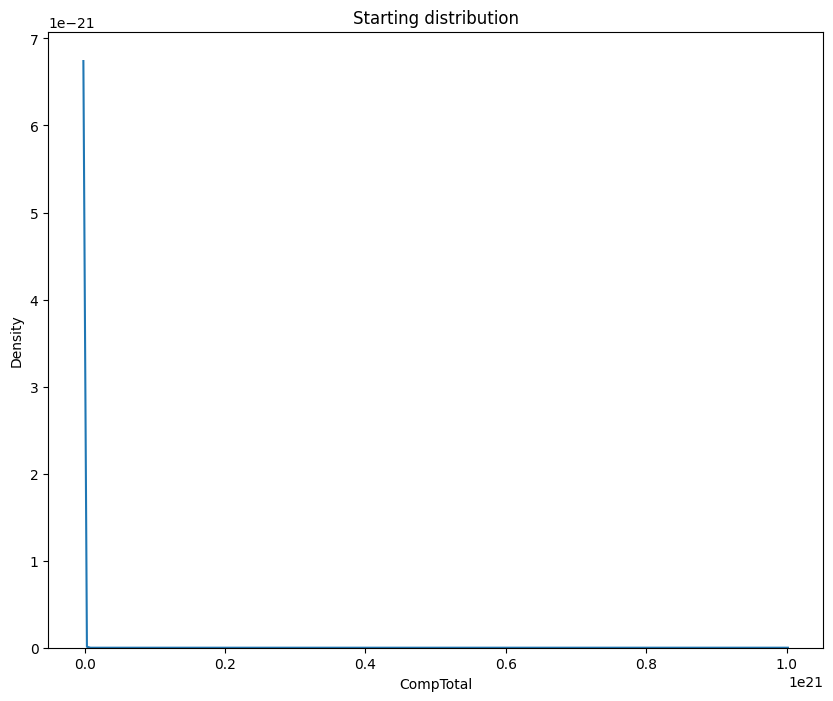

In [115]:
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Starting distribution')

sns.kdeplot(data_for_models['CompTotal'], ax=ax1, label ='beta')

In [116]:


data_for_models['CompTotal'] = np.where(
    data_for_models['CompTotal'] > 0,
    np.log1p(data_for_models['CompTotal']),
    data_for_models['CompTotal']
)

data_for_models.replace([np.inf, -np.inf], np.nan, inplace=True)

robust = RobustScaler()
data_for_models['CompTotal'] = robust.fit_transform(data_for_models[['CompTotal']])

<Axes: title={'center': 'New distribution'}, xlabel='CompTotal', ylabel='Density'>

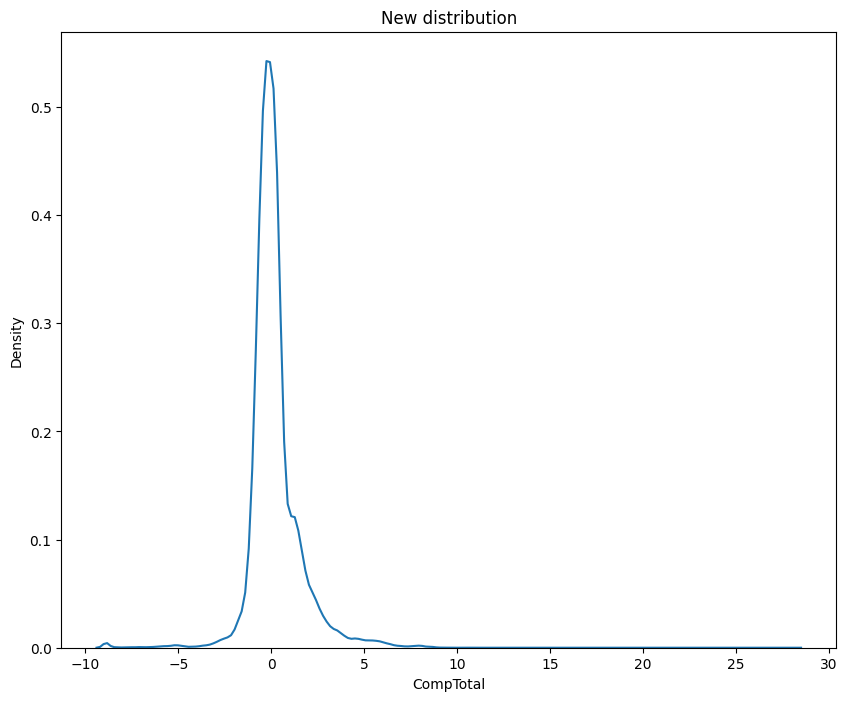

In [117]:
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('New distribution')

sns.kdeplot(data_for_models['CompTotal'], ax=ax1, label ='beta')

In [118]:
data_for_models = data_for_models.loc[:, ~data_for_models.columns.duplicated()]

data_for_models = data_for_models.loc[:, ~data_for_models.T.duplicated()]

In [119]:
df = data_for_models.copy()

# Doing the correlation matrix
corr = df.corr(numeric_only=True)

# Looking at the highest correlations
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)
print(corr_pairs[corr_pairs < 1].head(20))

YearsCodePro                                             Age_num                                                           0.804886
RemoteWork_Hybrid (some remote, some in-person)          RemoteWork_Remote                                                 0.774349
Currency_4                                               Currency_6                                                        0.584264
EdLevel_Master’s degree (M.A., M.S., M.Eng., MBA, etc.)  EdLevel_Bachelor’s degree (B.A., B.S., B.Eng., etc.)              0.561712
C                                                        C++                                                               0.539771
Country_5                                                Currency_4                                                        0.513012
Currency_1                                               Country_1                                                         0.479470
Currency_2                                               Country_2          

In [120]:
df = df.drop(columns=['Age_num', 'RemoteWork_Hybrid (some remote, some in-person)'])

In [121]:
df = data_for_models.copy()

y_all = df['CompTotal']
currency_counts = df['Currency'].value_counts()
rare_currencies = currency_counts[currency_counts < 10].index

df_rare = df[df['Currency'].isin(rare_currencies)]
df_main = df[~df['Currency'].isin(rare_currencies)]

X_train_main, X_test, y_train_main, y_test = train_test_split(
    df_main.drop(columns=['CompTotal']),
    df_main['CompTotal'],
    test_size=0.2,
    stratify=df_main['Currency'],
    random_state=42
)

X_train_main = X_train_main.drop(columns=['Currency'])
X_test = X_test.drop(columns=['Currency'])

X_train_rare = df_rare.drop(columns=['CompTotal', 'Currency'])
y_train_rare = df_rare['CompTotal']

X_train = pd.concat([X_train_main, X_train_rare], axis=0)
y_train = pd.concat([y_train_main, y_train_rare], axis=0)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train = X_train[numeric_cols].copy()

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Rare currencies got only into  train? ->", set(df_rare['Currency']).isdisjoint(set(df_main['Currency'].unique())))

Train shape: (28147, 112), Test shape: (6997, 112)
Rare currencies got only into  train? -> True


In [122]:
model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rrmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"rmse: {rrmse:.2f}")

MAE: 0.69
rmse: 1.25


In [123]:
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_
}).sort_values(by='coef', key=np.abs, ascending=False)

print("\nTop 20 values:")
print(coefs.head(20))


Top 20 values:
                                feature      coef
64                           Currency_0  2.646929
103                     DevType_Student -1.234770
56                            Country_0 -0.961363
67                           Currency_3  0.851703
66                           Currency_2  0.646651
78          DevType_Academic researcher -0.450510
44                                 Raku -0.411669
57                            Country_1 -0.397733
82         DevType_Developer Experience  0.391289
65                           Currency_1  0.390063
83          DevType_Engineering manager  0.334350
62                            Country_6 -0.312445
90   DevType_Engineer, site reliability  0.302023
98            DevType_Hardware Engineer -0.298097
68                           Currency_4  0.288037
101                    DevType_Educator -0.278832
95              DevType_Product manager  0.273890
70                           Currency_6  0.262932
75         DevType_System administ

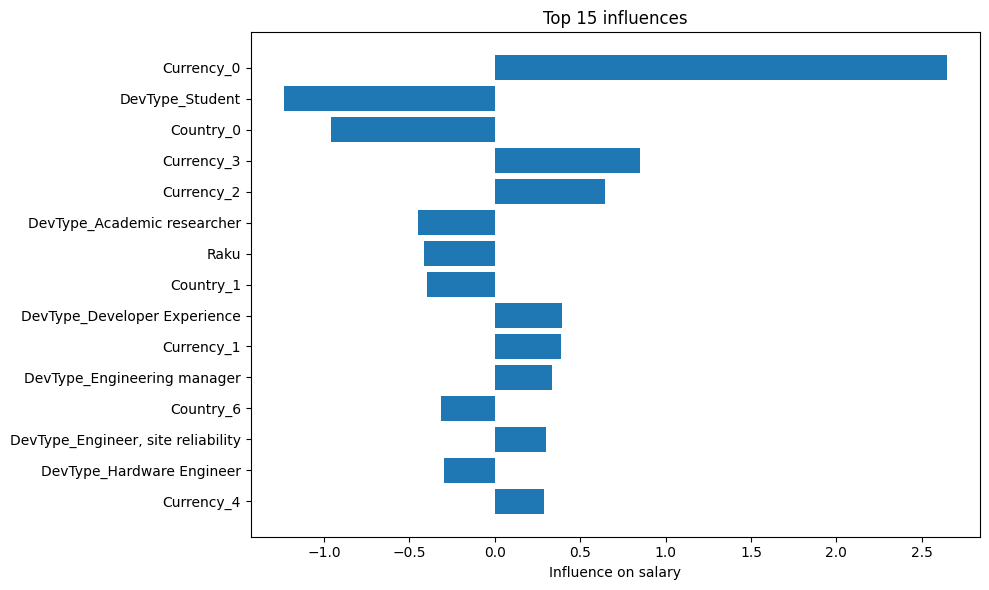

In [124]:
plt.figure(figsize=(10,6))
plt.barh(coefs['feature'].head(15)[::-1], coefs['coef'].head(15)[::-1])
plt.xlabel("Influence on salary")
plt.title("Top 15 influences")
plt.tight_layout()
plt.show()